In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:

%cd /content/drive/MyDrive/PPG_BP_Prediction
!ls -la

/content/drive/MyDrive/PPG_BP_Prediction
total 314
drwx------ 2 root root   4096 Mar 10 07:25 data
drwx------ 2 root root   4096 Mar 10 07:25 figures
-rw------- 1 root root 305440 Mar 10 07:19 march_sbp_dataset.npz
-rw------- 1 root root   2703 Mar 10 07:22 README.md
-rw------- 1 root root     55 Mar 10 06:52 requirements.txt
drwx------ 2 root root   4096 Mar 10 07:25 src


In [9]:
!pip -q install -r requirements.txt

In [16]:
from pathlib import Path
from pathlib import Path
from src.preprocess_march_sbp import _load_ppg_csv, _load_labels, _align_by_index
import numpy as np
import matplotlib.pyplot as plt
import torch


In [10]:
base = Path("/content/drive/MyDrive/PPG_BP_Prediction")
for p in ["data/derived/finger.csv","data/derived/wrist.csv","data/derived/labels.csv"]:
    print(p, (base/p).exists())

data/derived/finger.csv True
data/derived/wrist.csv True
data/derived/labels.csv True


In [11]:
march_dir = Path("data/derived")

finger = _load_ppg_csv(march_dir / "finger.csv")
wrist  = _load_ppg_csv(march_dir / "wrist.csv")
labels = _load_labels(march_dir / "labels.csv")

labels_a, f_ir, f_red, w_ir, w_red = _align_by_index(finger, wrist, labels)

print("aligned shapes:", f_ir.shape, f_red.shape, w_ir.shape, w_red.shape)
print("labels:", labels_a.shape)

aligned shapes: (34, 3000) (34, 3000) (34, 3000) (34, 3000)
labels: (34, 6)


In [12]:
# y_sbp and hr for downstream (training uses npz; pipeline produces X_raw, X_filt, X_ds, X_norm in previous cell)
y_sbp = labels_a["sbp"].to_numpy(dtype=float)
hr = labels_a["hr"].to_numpy(dtype=float).reshape(-1, 1)
print("y_sbp:", y_sbp.shape, "hr:", hr.shape)

X_raw: (34, 3000, 4) y: (34,) hr: (34, 1)


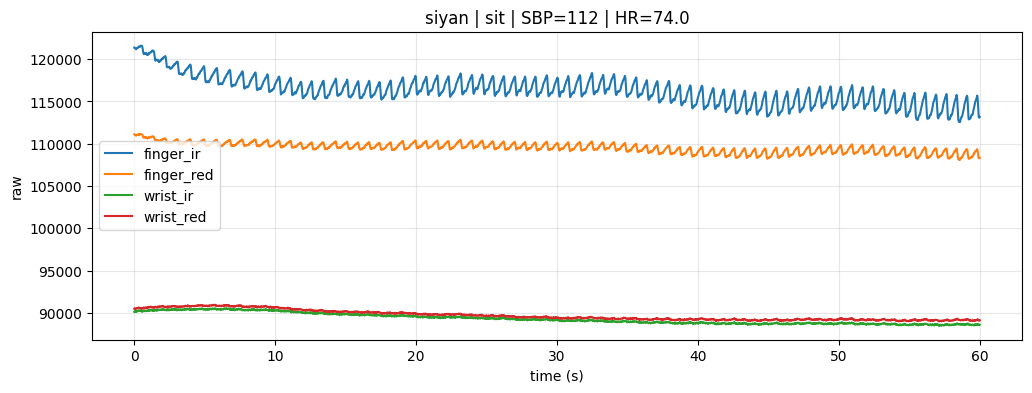

In [ ]:
names = labels_a["name"].astype(str).to_numpy()
states = labels_a["state"].astype(str).to_numpy()

chosen = None
for nm in np.unique(names):
    mask = names == nm
    if np.any(mask & (states == "sit")) and np.any(mask & (states == "plank")):
        chosen = nm
        break

if chosen is None:
    idx_sit, idx_plank = 0, min(1, X_raw.shape[0] - 1)
    title_suffix = ""
else:
    idx_sit = np.where((names == chosen) & (states == "sit"))[0][0]
    idx_plank = np.where((names == chosen) & (states == "plank"))[0][0]
    title_suffix = f" (subject={chosen})"

# Step-by-step preprocessing (presentation-friendly labels)
# NOTE: polarity inversion should be per-channel (per sample), not a single max across all channels.
# X_raw: (N, T, C)  -> X_pol: (N, T, C)
X_pol = np.max(X_raw, axis=1, keepdims=True) - X_raw

steps = [
    (X_pol, 50.0, "1) Polarity fix\n(per-channel max − x)", "a.u."),
    (X_filt, 50.0, "2) Bandpass\n0.5–8 Hz", "a.u."),
    (X_ds, 10.0, "3) Downsample\n50 → 10 Hz", "a.u."),
    (X_norm, 10.0, "4) Normalize\nz-score", "z-score"),
]
ch_names = ["finger_ir", "finger_red", "wrist_ir", "wrist_red"]

fig, axes = plt.subplots(len(steps), 2, figsize=(11.0, 10.0), sharex="col")
xticks = [0, 2, 4, 6, 8, 10]

for row, (X, fs, step_label, ylabel) in enumerate(steps):
    x_sit = X[idx_sit]
    x_plank = X[idx_plank]
    t_sit = np.arange(x_sit.shape[0]) / fs
    t_plank = np.arange(x_plank.shape[0]) / fs

    for ax, x, t, st in zip(axes[row], (x_sit, x_plank), (t_sit, t_plank), ("sit", "plank")):
        for ci, ch in enumerate(ch_names):
            ax.plot(
                t,
                x[:, ci],
                label=ch.replace("_", " "),
                color=COL.get(ch, "#666666"),
                alpha=0.85,
            )
        ax.set_title((( "Seated" if st == "sit" else "Plank") + title_suffix) if row == 0 else "")
        ax.set_xlim(0, 10)
        ax.set_xticks(xticks)
        ax.grid(True, alpha=0.2)

    axes[row, 0].set_ylabel(f"{step_label}\n[{ylabel}]", fontsize=10)
    if row == 0:
        leg = axes[row, 0].legend(frameon=True, ncol=1, loc="upper right", fontsize=8)
        leg.get_frame().set_edgecolor("#000000")
        leg.get_frame().set_linewidth(0.8)
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_alpha(1.0)

for ax in axes[-1]:
    ax.set_xlabel("Time (s)")

fig.suptitle("PPG preprocessing pipeline: Seated vs Plank posture", y=0.995)
fig.tight_layout()
plt.show()

###start training


## Presentation figures (recommended)

### 1) Signal processing comparison (Raw vs Clean PPG)

- **Layout**: 1 row × 2 columns.
  - **Left**: Raw PPG (with baseline drift + motion noise).
  - **Right**: Preprocessed PPG (bandpass + downsample + per-sample z-score).
- **What to show**:
  - Plot **finger IR** and **wrist IR** (or all 4 channels with thin lines) for a short window (e.g., 10–20 s) so the waveform is clearly visible.
  - Keep the **same time axis** and (optionally) the same y-scale to highlight cleaning.

### 2) Data alignment diagram (PPG + HR + BP points)

- **Layout**: 3 stacked panels sharing x-axis (time).
  - **Top**: PPG waveform (one channel is enough).
  - **Middle**: HR curve (line).
  - **Bottom**: BP cuff sampling points (scatter markers at measurement times, labeled SBP/DBP or SBP only).
- **Key message**: show how cuff timestamps map to the PPG timeline and how the 60 s windows are extracted.

### 3) Experiment protocol / data distribution (Sit / Lay / Plank)

- **Option A (cleanest)**: per-subject **timeline bar** (x=time/order, y=subject) with color-coded states.
- **Option B**: bar chart of **sample counts per state** + (optional) SBP/ΔSBP distribution per state (box/violin).
- **Recommended**: show both **count** and **SBP(ΔSBP) distribution** to justify class imbalance + physiological effect.

> Tip: For slides, prefer large fonts, minimal legends, and annotate the main takeaway directly on the figure.

In [ ]:
import os
from pathlib import Path

import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError("matplotlib is required for the presentation figures") from e

# Optional (for preprocessing demo)
try:
    from scipy.signal import butter, filtfilt
except Exception:
    butter = filtfilt = None


PROJECT_ROOT = Path.cwd()
DATA_DERIVED = PROJECT_ROOT / "data" / "derived"
NPZ_MARCH = PROJECT_ROOT / "march_sbp_dataset.npz"


def _bandpass(x: np.ndarray, fs: float = 50.0, lo: float = 0.5, hi: float = 8.0, order: int = 4) -> np.ndarray:
    if butter is None or filtfilt is None:
        raise RuntimeError("scipy is required for bandpass demo; install scipy or skip this cell")
    nyq = 0.5 * fs
    b, a = butter(order, [lo / nyq, hi / nyq], btype="bandpass")
    return filtfilt(b, a, x)


def _zscore(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    mu = np.mean(x)
    sd = np.std(x)
    sd = max(sd, eps)
    return (x - mu) / sd


def _load_derived_tables():
    if pd is None:
        raise RuntimeError("pandas is required for loading derived CSV tables")
    finger_path = DATA_DERIVED / "finger.csv"
    wrist_path = DATA_DERIVED / "wrist.csv"
    labels_path = DATA_DERIVED / "labels.csv"
    if not (finger_path.exists() and wrist_path.exists() and labels_path.exists()):
        raise FileNotFoundError(
            f"Missing derived tables. Expected: {finger_path}, {wrist_path}, {labels_path}"
        )
    finger = pd.read_csv(finger_path)
    wrist = pd.read_csv(wrist_path)
    labels = pd.read_csv(labels_path)
    return finger, wrist, labels


def fig1_raw_vs_clean_ppg(seed: int = 0, sec: float = 15.0):
    """Left: 'raw' from derived CSV, Right: filtered+downsampled+z-scored."""
    finger, wrist, labels = _load_derived_tables()

    # Pick one example row
    rng = np.random.default_rng(seed)
    row = int(rng.integers(0, len(labels)))

    # Columns: index + ir_0.. + red_0.. (same as preprocess_march_sbp)
    ir_cols = [c for c in finger.columns if c.startswith("ir_")]
    red_cols = [c for c in finger.columns if c.startswith("red_")]
    ir_cols = sorted(ir_cols, key=lambda s: int(s.split("_")[1]))
    red_cols = sorted(red_cols, key=lambda s: int(s.split("_")[1]))

    f_ir = finger.loc[row, ir_cols].to_numpy(dtype=float)
    w_ir = wrist.loc[row, ir_cols].to_numpy(dtype=float)

    fs = 50.0
    n = int(sec * fs)
    f_ir = f_ir[:n]
    w_ir = w_ir[:n]
    t = np.arange(len(f_ir)) / fs

    # Clean: bandpass -> downsample(5) -> zscore
    f_clean = _zscore(_bandpass(f_ir, fs=fs)[::5])
    w_clean = _zscore(_bandpass(w_ir, fs=fs)[::5])
    t2 = np.arange(len(f_clean)) / (fs / 5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=False)
    ax = axes[0]
    ax.plot(t, f_ir, label="Finger IR (raw)", lw=1.2)
    ax.plot(t, w_ir, label="Wrist IR (raw)", lw=1.2)
    ax.set_title("Raw PPG (baseline drift + noise)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, fontsize=9)

    ax = axes[1]
    ax.plot(t2, f_clean, label="Finger IR (clean)", lw=1.2)
    ax.plot(t2, w_clean, label="Wrist IR (clean)", lw=1.2)
    ax.set_title("Clean PPG (bandpass + downsample + z-score)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Z-score")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, fontsize=9)

    fig.tight_layout()
    return fig


def fig2_alignment_schematic():
    """A simple alignment schematic: PPG + HR + BP points with a 60s window."""
    # Use a synthetic 60s window and show the BP point at the end.
    if not NPZ_MARCH.exists():
        raise FileNotFoundError(f"Missing {NPZ_MARCH}. Run preprocessing first.")
    z = np.load(NPZ_MARCH, allow_pickle=True)
    X = z["X"].astype(np.float32)
    hr = z["hr"].astype(np.float32)
    y = z["y"].astype(np.float32)

    # Take the first sample as an example clean PPG
    ppg = X[0, :, 0]  # finger IR (already clean)
    fs = 10.0
    t = np.arange(len(ppg)) / fs
    bp_t = t[-1]

    fig, axes = plt.subplots(3, 1, figsize=(12, 5.8), sharex=True)

    axes[0].plot(t, ppg, lw=1.2)
    axes[0].axvspan(t[0], t[-1], alpha=0.10)
    axes[0].set_ylabel("PPG (clean)")
    axes[0].set_title("Alignment schematic: 60s PPG window, HR, and cuff BP point")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot([t[0], t[-1]], [float(hr[0, 0]), float(hr[0, 0])], lw=2)
    axes[1].set_ylabel("HR (z-score)")
    axes[1].grid(True, alpha=0.25)

    axes[2].scatter([bp_t], [float(y[0])], s=60)
    axes[2].annotate(f"SBP={float(y[0]):.0f}", (bp_t, float(y[0])), xytext=(8, 8), textcoords="offset points")
    axes[2].set_ylabel("SBP (mmHg)")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.25)

    fig.tight_layout()
    return fig


def fig3_protocol_distribution():
    """State distribution + SBP distribution (boxplot) for Sit/Lay/Plank."""
    if pd is None:
        raise RuntimeError("pandas is required for this figure")
    if not NPZ_MARCH.exists():
        raise FileNotFoundError(f"Missing {NPZ_MARCH}. Run preprocessing first.")

    z = np.load(NPZ_MARCH, allow_pickle=True)
    y = z["y"].astype(np.float32)
    state = np.array([str(s).lower() for s in z["state"]], dtype=object)

    # Normalize state names
    def norm(s: str) -> str:
        if "plank" in s:
            return "plank"
        if s in {"sit", "sitting"}:
            return "sit"
        if s in {"lay", "lying", "lie"}:
            return "lay"
        return s

    state_n = np.array([norm(s) for s in state], dtype=object)
    order = ["sit", "lay", "plank"]

    counts = {k: int(np.sum(state_n == k)) for k in order}

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

    # Left: counts
    axes[0].bar(list(counts.keys()), list(counts.values()))
    axes[0].set_title("Sample counts by posture")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, axis="y", alpha=0.25)

    # Right: SBP distribution
    data = [y[state_n == k] for k in order]
    axes[1].boxplot(data, labels=order, showfliers=False)
    axes[1].set_title("SBP distribution by posture")
    axes[1].set_ylabel("SBP (mmHg)")
    axes[1].grid(True, axis="y", alpha=0.25)

    fig.tight_layout()
    return fig


# Generate all three figures
fig1_raw_vs_clean_ppg()
fig2_alignment_schematic()
fig3_protocol_distribution()
plt.show()

In [15]:
print("cuda_available:", torch.cuda.is_available())
print("device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
!nvidia-smi

cuda_available: True
device: cuda
Tue Mar 10 07:31:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------

In [26]:
!python src/train_march_sbp_torch.py --data march_sbp_dataset.npz --save-dir results/all_train --plot

Device: cuda (cuda_available=True)
  epoch   0 train_loss=116.6284 val_loss=120.4688 val_mae=120.969
  epoch  20 train_loss=106.6967 val_loss=106.2443 val_mae=106.744
  epoch  40 train_loss=85.9059 val_loss=88.2924 val_mae=88.792
  epoch  60 train_loss=60.8644 val_loss=64.4851 val_mae=64.985
  epoch  80 train_loss=31.2974 val_loss=35.9416 val_mae=36.442
  epoch 100 train_loss=12.9759 val_loss=12.7773 val_mae=13.245
  epoch 120 train_loss=10.7843 val_loss=12.5049 val_mae=13.003
  epoch 140 train_loss=9.4569 val_loss=9.9674 val_mae=10.467
  epoch 160 train_loss=6.4434 val_loss=13.8679 val_mae=14.368
  epoch 180 train_loss=7.4715 val_loss=11.7389 val_mae=12.239
------------------------------------------------------------
VAL: MAE=8.017, RMSE=12.588, R2=0.543
Wrote results/all_train/best_state_dict.pt and results/all_train/metrics.npz
Wrote results/all_train/loss_curves.png


In [44]:
!python src/train_march_state_torch.py --data march_sbp_dataset.npz --mode three_class --save-dir results/state_3class --plot

Device: cuda (cuda_available=True)
  epoch   0 train_loss=1.0684 val_loss=1.0850 val_acc=0.429
  epoch  20 train_loss=0.0586 val_loss=1.5366 val_acc=0.429
  epoch  40 train_loss=0.0176 val_loss=1.3905 val_acc=0.571
------------------------------------------------------------
MODE=three_class classes=['sit', 'lay', 'plank']
VAL: ACC=0.714, F1(macro)=0.552
TEST: ACC=0.714, F1(macro)=0.700
TEST confusion matrix (rows=true, cols=pred):
[[1 1 1]
 [0 2 0]
 [0 0 2]]
Wrote results/state_3class/best_state_dict.pt and results/state_3class/metrics.npz
Wrote results/state_3class/confusion_matrix.png


In [36]:
!python src/train_march_state_torch.py \
  --data march_sbp_dataset.npz \
  --mode binary \
  --save-dir results/state_binary \
  --plot

Device: cuda (cuda_available=True)
  epoch   0 train_loss=0.6053 val_loss=0.5686 val_acc=0.857
  epoch  20 train_loss=0.0040 val_loss=0.0069 val_acc=1.000
------------------------------------------------------------
MODE=binary classes=['rest(sit+lay)', 'plank']
VAL: ACC=1.000, F1(macro)=1.000
TEST: ACC=1.000, F1(macro)=1.000
TEST confusion matrix (rows=true, cols=pred):
[[5 0]
 [0 2]]
Wrote results/state_binary/best_state_dict.pt and results/state_binary/metrics.npz
Wrote results/state_binary/confusion_matrix.png


In [ ]:
!python src/train_march_sbp_ppg_only_torch.py --data march_sbp_dataset.npz --save-dir results/sbp_ppg_only --plot